In [42]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification
from sklearn.preprocessing import MinMaxScaler
from collections import Counter

In [43]:
X,y = make_classification(
    n_samples=2000,
    n_features=2,
    n_redundant=0,
    n_clusters_per_class=1,
    random_state=42
)

In [44]:
scaler=MinMaxScaler()
X=scaler.fit_transform(X)

In [45]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [46]:
def euclidean_distance(x1, x2):
    return np.sqrt(np.sum((x1 - x2) ** 2))

In [47]:
def knn_predict(X_train, y_train, x_test, k):
    distance = []
    
    for i in range(len(X_train)):
        dist = euclidean_distance(x_test, X_train[i])
        distance.append((dist, y_train[i]))
        
    distance.sort(key=lambda x: x[0])
    
    neighbours = distance[:k]
    labels = [label for _, label in neighbours]
    
    most_common = Counter(labels).most_common(1)
    
    return most_common[0][0]

For k = 1 predicted class is: 1
Accuracy for k = 1 is 0.925
For k = 3 predicted class is: 1
Accuracy for k = 3 is 0.9475
For k = 5 predicted class is: 1
Accuracy for k = 5 is 0.945
For k = 7 predicted class is: 1
Accuracy for k = 7 is 0.9475


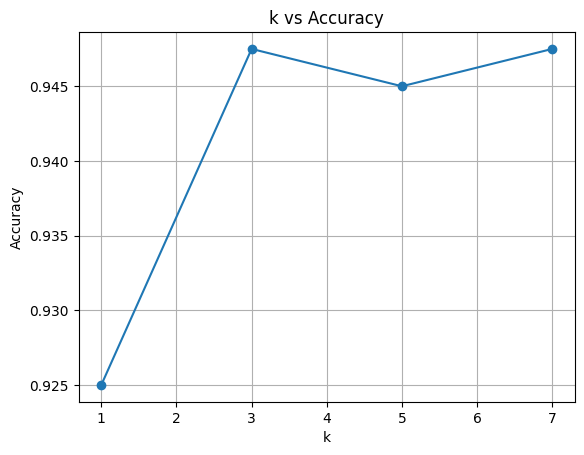

In [48]:
k_values = [1, 3, 5, 7]
accuracies = []

for k in k_values:
    predictions = []

    for x in X_test:
        pred = knn_predict(X_train, y_train, x, k)
        predictions.append(pred)

    predictions = np.array(predictions)

    final_prediction = np.bincount(predictions).argmax()
    print("For k =", k, "predicted class is:", final_prediction)

    accuracy = np.sum(predictions == y_test) / len(y_test)
    accuracies.append(accuracy)
    print("Accuracy for k =", k, "is", accuracy)

# Plot k vs accuracy
plt.plot(k_values, accuracies, marker='o')
plt.xlabel("k")
plt.ylabel("Accuracy")
plt.title("k vs Accuracy")
plt.grid(True)
plt.show()

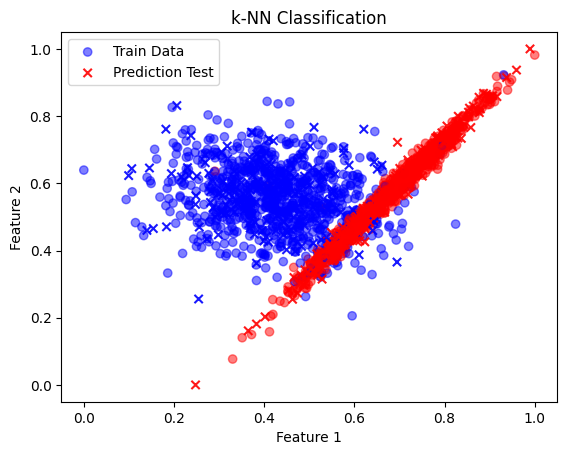

In [49]:
plt.scatter(X_train[:,0],X_train[:,1],c=y_train,cmap='bwr',marker='o',alpha=0.5,label="Train Data")
plt.scatter(X_test[:,0],X_test[:,1],c=predictions,cmap='bwr',marker='x',alpha=0.9,label="Prediction Test")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("k-NN Classification")
plt.legend()
plt.show()